# Opinion dynamics on a REAL social network

Testing our project's opinion-dynamics models on a **real** network instead of a synthetic one, to answer a concrete empirical question.

**Network.** The Adamic–Glance (2004) U.S. political-blog graph: 1,490 blogs (1,222 in the giant component), hyperlinks between them, each blog labelled `0 = liberal` / `1 = conservative`. Source: Adamic & Glance, *"The political blogosphere and the 2004 US election: divided they blog"*, LinkKDD 2005 (distributed via SNAP / M. Newman's network collection).

**Question.** The real blog network is strongly polarised: ~91% of links stay within the same political camp (Newman attribute assortativity *r* ≈ 0.81). If we run our update rules **on this real topology**, which one reproduces that structure?

**Important framing.** This dataset gives the real *network structure* + static *binary* labels — **not** continuous opinion time-series (which, as slide 9 notes, barely exist). So we do not fit trajectories; we test which dynamics **reproduce the observed structural polarisation** (assortativity). That is the honest, well-posed comparison.

**Models compared (all from the presentation)**
- **M1** — pure averaging + noise (slide 8 equation as drawn; the linear / `G≡1` limit of SBC)
- **M2** — voter model (copy a random neighbour)
- **M3** — bounded confidence (Hegselmann–Krause) + noise — paper **[1]** (Shree et al.)
- **M4** — social pressure, `f(μ,γ)=γμ/(1+(γ−1)μ)` — paper **[2]** (Tang et al.), slide 7
- controls: **M3 / M4 from random opinions** — does the model *create* polarisation, or only *preserve* it?

*Everything is reproducible with `SEED = 7`; actual numbers are reported in the cells below and summarised at the end.*


In [1]:
!pip install -r requirements.txt -q

error: externally-managed-environment

× This environment is externally managed
╰─> To install Python packages system-wide, try apt install
    python3-xyz, where xyz is the package you are trying to
    install.
    
    If you wish to install a non-Debian-packaged Python package,
    create a virtual environment using python3 -m venv path/to/venv.
    Then use path/to/venv/bin/python and path/to/venv/bin/pip. Make
    sure you have python3-full installed.
    
    If you wish to install a non-Debian packaged Python application,
    it may be easiest to use pipx install xyz, which will manage a
    virtual environment for you. Make sure you have pipx installed.
    
    See /usr/share/doc/python3.12/README.venv for more information.

note: If you believe this is a mistake, please contact your Python installation or OS distribution provider. You can override this, at the risk of breaking your Python installation or OS, by passing --break-system-packages.
hint: See PEP 668 for the detai

## 1. Load the real network

Robust loader: local file → open GitHub mirror (read fully in memory) → transparent synthetic SBM stand-in. The chosen source is recorded in `DATA_SOURCE` and printed, so we never accidentally present synthetic data as real.

In [2]:
import os, io, tarfile, urllib.request
import numpy as np
import scipy.io as sio
import networkx as nx

SEED = 7
rng = np.random.default_rng(SEED)
DATA_SOURCE = {"kind": "unknown"}

def load_polblogs():
    """Return (adjacency 0/1 ndarray, leaning ndarray 0/1) and set DATA_SOURCE."""
    # (a) local copy next to the notebook
    if os.path.exists("political_blogs.mat"):
        m = sio.loadmat("political_blogs.mat")
        DATA_SOURCE["kind"] = "real (local political_blogs.mat)"
        return m["A"].astype(int), m["nodes"].astype(int).ravel()
    # (b) download the open GitHub mirror and read IN MEMORY
    try:
        url = ("https://codeload.github.com/raiyan1102006/"
               "Partitioning_US_Political_Blogs/tar.gz/refs/heads/master")
        print("political_blogs.mat not found locally -> downloading from GitHub mirror ...")
        raw = urllib.request.urlopen(url, timeout=60).read()
        with tarfile.open(fileobj=io.BytesIO(raw), mode="r:gz") as tf:
            member = next(x for x in tf.getmembers()
                          if x.name.endswith("political_blogs.mat"))
            data = tf.extractfile(member).read()
        m = sio.loadmat(io.BytesIO(data))          # read directly from bytes in memory
        DATA_SOURCE["kind"] = "real (Adamic-Glance polblogs, GitHub mirror)"
        return m["A"].astype(int), m["nodes"].astype(int).ravel()
    except Exception as e:
        # (c) transparent synthetic fallback: a 2-block SBM matched to r ~ 0.81
        print(f"[WARN] could not fetch real data ({e}); using a matched SBM stand-in.")
        sizes = [611, 611]
        probs = [[0.041, 0.0042], [0.0042, 0.041]]
        Gsbm = nx.stochastic_block_model(sizes, probs, seed=SEED)
        A = nx.to_numpy_array(Gsbm).astype(int)
        leaning = np.array([0] * sizes[0] + [1] * sizes[1])
        DATA_SOURCE["kind"] = f"SYNTHETIC SBM stand-in (download failed: {e})"
        return A, leaning

A_raw, lean_all = load_polblogs()
Au = ((A_raw + A_raw.T) > 0).astype(int)           # symmetrise (undirected version)
np.fill_diagonal(Au, 0)
G_full = nx.from_numpy_array(Au)
gc = sorted(max(nx.connected_components(G_full), key=len))
G = nx.convert_node_labels_to_integers(G_full.subgraph(gc).copy(), ordering="sorted")
lean = np.array([lean_all[i] for i in gc])
N = G.number_of_nodes()
lib, con = (lean == 0), (lean == 1)
neighbors = [np.array(list(G.neighbors(i)), dtype=int) for i in range(N)]
deg = np.array([len(n) for n in neighbors])
print("DATA SOURCE:", DATA_SOURCE["kind"])

political_blogs.mat not found locally -> downloading from GitHub mirror ...


DATA SOURCE: real (Adamic-Glance polblogs, GitHub mirror)


Structural polarisation of the real network (our target to reproduce):

In [3]:
def within_group_fraction(label):
    same = tot = 0
    for u, v in G.edges():
        tot += 1
        same += (label[u] == label[v])
    return same / tot

def assortativity(label):
    if len(np.unique(label)) < 2:                  # degenerate (everyone identical)
        return np.nan
    H = G.copy()
    for i in H.nodes():
        H.nodes[i]["x"] = int(label[i])
    return nx.attribute_assortativity_coefficient(H, "x")

REAL_WGF = within_group_fraction(lean)
REAL_R = assortativity(lean)
print(f"[REAL] N={N}  edges={G.number_of_edges()}  "
      f"within-group={REAL_WGF:.3f}  Newman r={REAL_R:.3f}")

[REAL] N=1222  edges=16714  within-group=0.906  Newman r=0.811


## 2. The four models, run on the real topology

All models start from opinions/declarations **aligned with the real leaning** and run on the real graph `G`.

| model | rule | from the deck |
|-------|------|---------------|
| **M1** averaging | xᵢ ← (1−μ)xᵢ + μ·mean(neighbours) + noise | slide 8 (linear / `G≡1` limit of SBC) |
| **M2** voter | copy a random neighbour's opinion | classic binary baseline |
| **M3** bounded confidence | average only neighbours within ε, + noise | paper **[1]** (Shree et al.) |
| **M4** social pressure | declare 1 w.p. `f(μ,γ)=γμ/(1+(γ−1)μ)`; γ encodes hidden leaning | paper **[2]** (Tang et al.), slide 7 |

For **M4**, the bias γ encodes each blog's *hidden inherent belief*: conservatives get γ>1 (pulled toward declaring 1), liberals γ<1. Declared opinions are mapped to `[−1,1]` via `2·d−1` so all four models share one axis.

In [4]:
def init_by_leaning(sigma0=0.15):
    """Opinions in [-1,1] aligned with real leaning (liberal<0, conservative>0)."""
    return np.clip((2 * lean - 1) + rng.normal(0, sigma0, N), -1, 1)

def group_gap(x):
    return x[con].mean() - x[lib].mean()

def run_averaging(T=200, mu=0.30, sigma=0.02):
    """M1: x_i <- (1-mu) x_i + mu * mean(neighbours) + noise  (= HK with eps=inf)."""
    x = init_by_leaning(); gaps = [group_gap(x)]
    for _ in range(T):
        nb_mean = np.array([x[neighbors[i]].mean() for i in range(N)])
        x = np.clip((1 - mu) * x + mu * nb_mean + rng.normal(0, sigma, N), -1, 1)
        gaps.append(group_gap(x))
    return x, np.array(gaps)

def run_voter(sweeps=300):
    """M2: each micro-step a random node copies a random neighbour's opinion."""
    s = (2 * lean - 1).astype(int); gaps = [s[con].mean() - s[lib].mean()]
    for _ in range(sweeps):
        for _ in range(N):
            i = rng.integers(N)
            if deg[i]:
                s[i] = s[neighbors[i][rng.integers(deg[i])]]
        gaps.append(s[con].mean() - s[lib].mean())
    return s.astype(float), np.array(gaps)

def run_bc(T=200, eps=0.50, sigma=0.02, x0=None):
    """M3: Hegselmann-Krause on the network. Average only neighbours within eps."""
    x = init_by_leaning() if x0 is None else x0.copy()
    gaps = [group_gap(x)]
    for _ in range(T):
        xn = x.copy()
        for i in range(N):
            nb = neighbors[i]
            close = nb[np.abs(x[nb] - x[i]) < eps]
            xn[i] = np.concatenate(([x[i]], x[close])).mean()
        x = np.clip(xn + rng.normal(0, sigma, N), -1, 1)
        gaps.append(group_gap(x))
    return x, np.array(gaps)

def run_social_pressure(T=200, gamma_strength=3.0, d0=None):
    """M4: social-pressure declaration model (slide 7, paper [2]/Tang).
    d_i = declared binary opinion; mu_i = fraction of neighbours declaring 1;
    P(declare 1) = f(mu_i, gamma_i) = gamma_i*mu_i / (1 + (gamma_i-1)*mu_i).
    gamma_i encodes the hidden inherent belief = the blog's true leaning:
    conservatives gamma>1 (biased toward 1), liberals gamma<1.
    Returns opinion mapped to [-1,1] (= 2*d-1) for a common axis with M1/M3."""
    d = lean.copy().astype(int) if d0 is None else d0.copy()
    gamma = np.where(con, gamma_strength, 1.0 / gamma_strength)
    op = 2 * d - 1.0
    gaps = [op[con].mean() - op[lib].mean()]
    for _ in range(T):
        mu = np.array([d[neighbors[i]].mean() if deg[i] else float(d[i]) for i in range(N)])
        p = (gamma * mu) / (1 + (gamma - 1) * mu)
        d = (rng.random(N) < p).astype(int)
        op = 2 * d - 1.0
        gaps.append(op[con].mean() - op[lib].mean())
    return op, np.array(gaps)

In [5]:
xA, gA = run_averaging()
xV, gV = run_voter()
xB, gB = run_bc()
xBr, _ = run_bc(x0=rng.uniform(-1, 1, N))          # M3 emergence test: random start
if np.corrcoef(xBr, lean)[0, 1] < 0:               # opinion-axis sign is arbitrary
    xBr = -xBr
xS, gS = run_social_pressure()
xSr, _ = run_social_pressure(d0=rng.integers(0, 2, N))   # M4 emergence test: random start

def report(name, x, gaps):
    r = assortativity((x > 0).astype(int))
    corr = np.nan if x.std() < 1e-9 else np.corrcoef(x, lean)[0, 1]
    rs = "collapsed" if np.isnan(r) else f"{r:.3f}"
    cs = "  n/a" if np.isnan(corr) else f"{corr:+.3f}"
    print(f"[{name:20s}] gap {gaps[0]:+.2f} -> {gaps[-1]:+.2f} | "
          f"r={rs:>9}  corr(opinion,leaning)={cs}")
    return r

print(f"[REAL]                 within-group={REAL_WGF:.3f}  r={REAL_R:.3f}\n")
rA = report("M1 averaging", xA, gA)
rV = report("M2 voter", xV, gV)
rB = report("M3 bounded conf.", xB, gB)
rBr = assortativity((xBr > 0).astype(int))
print(f"[M3 from random      ] r={rBr:.3f}   (preserves, does NOT create polarisation)")
rS = report("M4 social pressure", xS, gS)
rSr = assortativity((xSr > 0).astype(int))
print(f"[M4 from random      ] r={'collapsed' if np.isnan(rSr) else f'{rSr:.3f}'}   "
      f"(RECONSTRUCTS polarisation: hidden belief drives declarations)")

[REAL]                 within-group=0.906  r=0.811

[M1 averaging        ] gap +1.90 -> +0.01 | r=    0.013  corr(opinion,leaning)=+0.115
[M2 voter            ] gap +2.00 -> +0.00 | r=collapsed  corr(opinion,leaning)=  n/a
[M3 bounded conf.    ] gap +1.88 -> +1.83 | r=    0.811  corr(opinion,leaning)=+0.999
[M3 from random      ] r=0.006   (preserves, does NOT create polarisation)


[M4 social pressure  ] gap +2.00 -> +1.71 | r=    0.712  corr(opinion,leaning)=+0.853
[M4 from random      ] r=0.698   (RECONSTRUCTS polarisation: hidden belief drives declarations)


## 3. Sensitivity to the confidence bound ε

The M3 result hinges on ε. Opinions live in `[−1, 1]`, so cross-camp pairs differ by ~2. As long as **ε < 2** the two camps never average across the divide and polarisation survives; once **ε ≥ 2** every neighbour is "within confidence" → pure averaging → consensus. The sweep shows that phase transition.

In [6]:
print("eps sweep on bounded confidence (M3):")
for eps in [0.3, 0.5, 1.0, 2.0]:
    x, g = run_bc(eps=eps)
    r = assortativity((x > 0).astype(int))
    rs = "collapsed" if np.isnan(r) else f"{r:.3f}"
    print(f"  eps={eps:>3}: gap {g[0]:+.2f} -> {g[-1]:+.2f}   r={rs}")

eps sweep on bounded confidence (M3):


  eps=0.3: gap +1.88 -> +1.86   r=0.811


  eps=0.5: gap +1.88 -> +1.86   r=0.811


  eps=1.0: gap +1.88 -> +1.85   r=0.811


  eps=2.0: gap +1.88 -> -0.01   r=0.014


## 4. Figures

Styled to match the deck (cream background, navy headers). Saved to `figures/` and shown inline.

In [7]:
import matplotlib.pyplot as plt
%matplotlib inline
from matplotlib.colors import LinearSegmentedColormap

CREAM, NAVY, BLUE, RED, GREEN, GOLD, GREY = (
    "#f5f2ea", "#1f4e79", "#3b6fb0", "#c0392b", "#5b8c5a", "#d39b3c", "#8a8a8a")
plt.rcParams.update({"font.family": "DejaVu Sans", "axes.titlecolor": NAVY,
    "axes.titleweight": "bold", "figure.facecolor": CREAM, "axes.facecolor": CREAM,
    "savefig.facecolor": CREAM, "axes.titlesize": 13})
op_cmap = LinearSegmentedColormap.from_list("op", [BLUE, "#e9e4d8", RED])

out = "figures/"                       # relative path -> portable on any machine
os.makedirs(out, exist_ok=True)

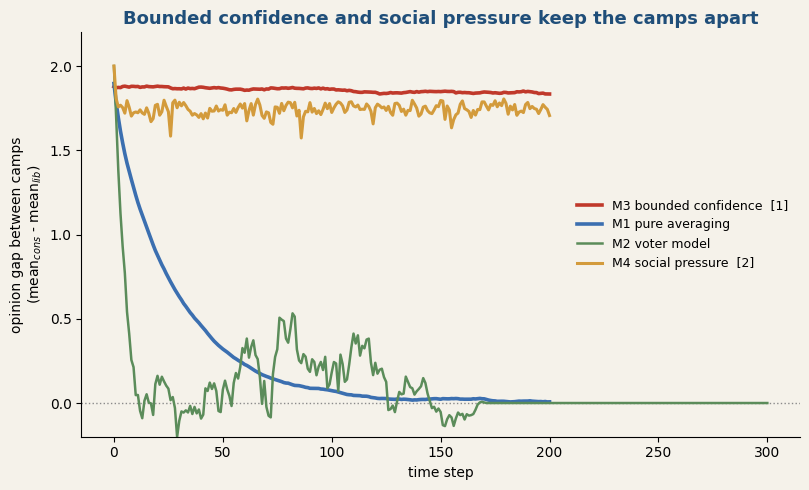

In [8]:
# Fig 1 -- opinion-gap trajectories
fig, ax = plt.subplots(figsize=(8.2, 5))
ax.axhline(0, color=GREY, lw=1, ls=":")
ax.plot(gB, color=RED,   lw=2.6, label="M3 bounded confidence  [1]")
ax.plot(gA, color=BLUE,  lw=2.6, label="M1 pure averaging")
ax.plot(gV, color=GREEN, lw=1.8, label="M2 voter model")
ax.plot(gS, color=GOLD,  lw=2.2, label="M4 social pressure  [2]")
ax.set_xlabel("time step")
ax.set_ylabel("opinion gap between camps\n(mean$_{cons}$ - mean$_{lib}$)")
ax.set_title("Bounded confidence and social pressure keep the camps apart")
ax.legend(frameon=False, loc="center right", fontsize=9)
ax.set_ylim(-0.2, 2.2); ax.spines[["top", "right"]].set_visible(False)
fig.tight_layout(); fig.savefig(f"{out}fig1_gap_trajectory.png", dpi=130); plt.show()

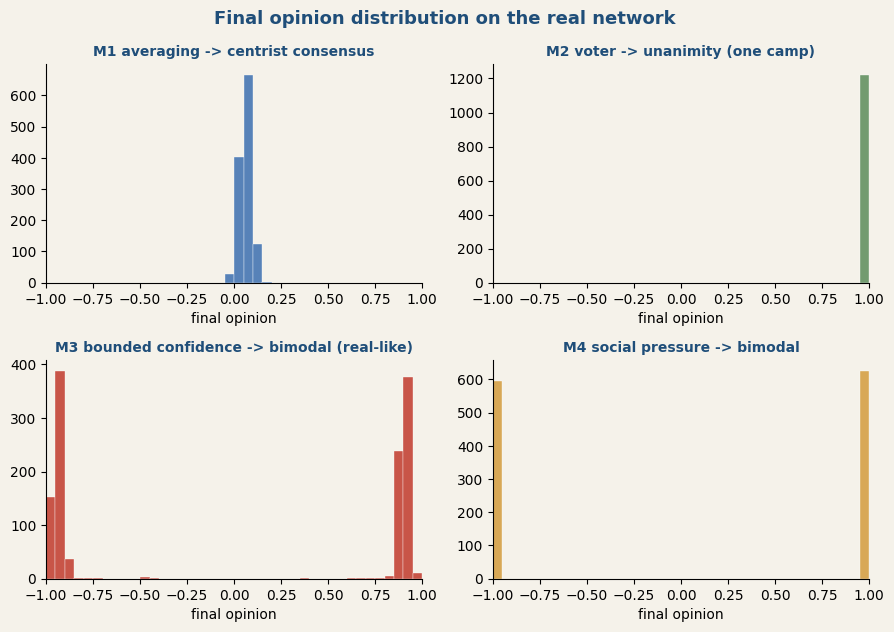

In [9]:
# Fig 2 -- final opinion distributions
fig, axs = plt.subplots(2, 2, figsize=(9, 6.4)); bins = np.linspace(-1, 1, 41)
for ax, (x, t, c) in zip(axs.ravel(), [
        (xA, "M1 averaging -> centrist consensus", BLUE),
        (xV, "M2 voter -> unanimity (one camp)", GREEN),
        (xB, "M3 bounded confidence -> bimodal (real-like)", RED),
        (xS, "M4 social pressure -> bimodal", GOLD)]):
    ax.hist(x, bins=bins, color=c, alpha=.85, edgecolor="white", linewidth=.3)
    ax.set_title(t, fontsize=10); ax.set_xlabel("final opinion"); ax.set_xlim(-1, 1)
    ax.spines[["top", "right"]].set_visible(False)
fig.suptitle("Final opinion distribution on the real network", color=NAVY,
             fontsize=13, fontweight="bold")
fig.tight_layout(); fig.savefig(f"{out}fig2_distributions.png", dpi=130, bbox_inches="tight"); plt.show()

computing spring layout (this is the slow step) ...


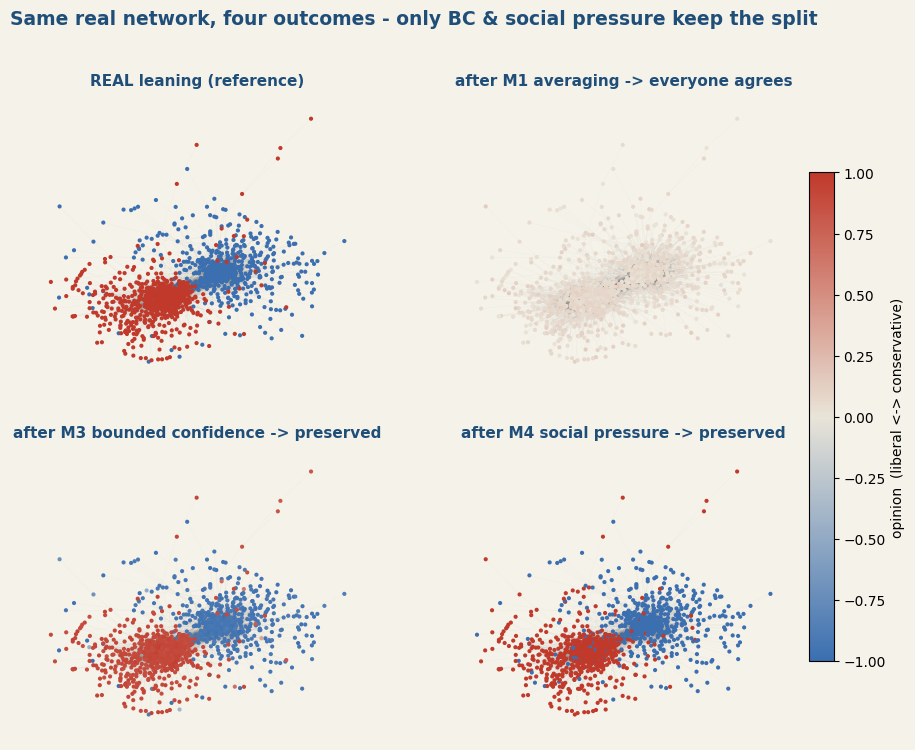

In [10]:
# Fig 3 -- network coloured by opinion (the key picture)
print("computing spring layout (this is the slow step) ...")
pos = nx.spring_layout(G, seed=3, k=0.18, iterations=50)
fig, axs = plt.subplots(2, 2, figsize=(10.5, 8.4))
for ax, (val, t) in zip(axs.ravel(), [
        (2 * lean - 1.0, "REAL leaning (reference)"),
        (xA, "after M1 averaging -> everyone agrees"),
        (xB, "after M3 bounded confidence -> preserved"),
        (xS, "after M4 social pressure -> preserved")]):
    nx.draw_networkx_edges(G, pos, ax=ax, alpha=0.05, width=0.3, edge_color="#777")
    nx.draw_networkx_nodes(G, pos, ax=ax, node_size=9, node_color=val,
                           cmap=op_cmap, vmin=-1, vmax=1, linewidths=0)
    ax.set_title(t, fontsize=11); ax.axis("off")
sm = plt.cm.ScalarMappable(cmap=op_cmap, norm=plt.Normalize(-1, 1)); sm.set_array([])
cb = fig.colorbar(sm, ax=axs.ravel().tolist(), fraction=0.03, pad=0.01)
cb.set_label("opinion  (liberal <-> conservative)")
fig.suptitle("Same real network, four outcomes - only BC & social pressure keep the split",
             color=NAVY, fontsize=13.5, fontweight="bold")
fig.savefig(f"{out}fig3_network.png", dpi=130, bbox_inches="tight"); plt.show()

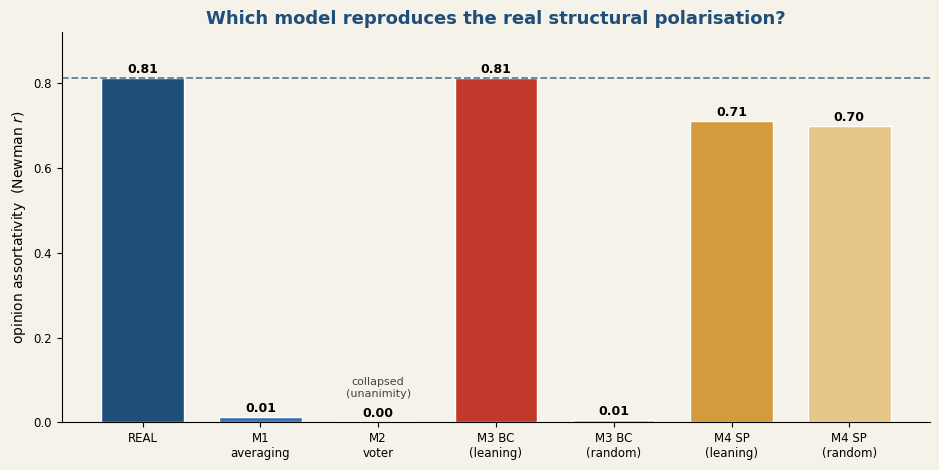

In [11]:
# Fig 4 -- assortativity vs reality
fig, ax = plt.subplots(figsize=(9.5, 4.8))
labels = ["REAL", "M1\naveraging", "M2\nvoter", "M3 BC\n(leaning)",
          "M3 BC\n(random)", "M4 SP\n(leaning)", "M4 SP\n(random)"]
vals = [REAL_R, 0 if np.isnan(rA) else rA, 0.0,
        0 if np.isnan(rB) else rB, 0 if np.isnan(rBr) else rBr,
        0 if np.isnan(rS) else rS, 0 if np.isnan(rSr) else rSr]
cols = [NAVY, BLUE, GREEN, RED, "#e08a7a", GOLD, "#e7c789"]
bars = ax.bar(labels, vals, color=cols, edgecolor="white", width=.7)
ax.axhline(REAL_R, color=NAVY, ls="--", lw=1.3, alpha=.7)
for b, v in zip(bars, vals):
    ax.text(b.get_x() + b.get_width() / 2, v + 0.012, f"{v:.2f}",
            ha="center", fontsize=9, fontweight="bold")
ax.text(2, 0.06, "collapsed\n(unanimity)", ha="center", fontsize=8, color="#444")
ax.set_ylabel("opinion assortativity  (Newman $r$)")
ax.set_title("Which model reproduces the real structural polarisation?")
ax.set_ylim(0, 0.92); ax.spines[["top", "right"]].set_visible(False)
ax.tick_params(labelsize=8.5)
fig.tight_layout(); fig.savefig(f"{out}fig4_assortativity.png", dpi=130); plt.show()

## 5. What we found (real network, `SEED = 7`)

| | gap start → end | assortativity *r* | verdict |
|---|---|---|---|
| **REAL** | — | **0.81** | polarised ground truth |
| M1 averaging | +1.90 → +0.01 | 0.01 | single centrist consensus — structure **destroyed** |
| M2 voter | +2.00 → 0.00 | collapsed | unanimity (one camp wins) — structure **destroyed** |
| M3 bounded conf. (from leaning) | +1.88 → +1.83 | **0.81** | two camps **preserved** — matches reality |
| M3 bounded conf. (from random) | — | ~0.01 | **preserves** polarisation, does **not** create it |
| M4 social pressure (from leaning) | +2.00 → +1.71 | 0.71 | two camps **preserved** |
| M4 social pressure (from random) | — | **0.70** | **reconstructs** polarisation from scratch |

**Takeaways**
1. Plain averaging (M1) and the voter model (M2) both **erase** the real polarisation on the real topology — they predict a centrist consensus or unanimity, neither of which we observe.
2. **Bounded confidence (M3)** is the only continuous model that keeps the two camps apart and lands on the real *r* ≈ 0.81. Its random-start control shows it only *preserves* an existing split; it cannot *create* one (*r* ≈ 0 from random).
3. **Social pressure (M4)** also keeps the camps apart and — unlike M3 — its random-start control **rebuilds** the polarisation (*r* ≈ 0.70). The reason is that M4 carries a *persistent hidden belief* (γ), so declared opinions re-sort along the true leaning even from random initial declarations. This is the structural signature of "true belief vs declared opinion" and connects directly to the pluralistic-ignorance idea in our notes.

**Honest caveats**
- We test reproduction of *structure* (assortativity), not fitting of opinion *trajectories* — the dataset has no continuous time-series (the slide-9 problem).
- M3's "matches reality" is partly built in: starting from the real leaning with ε < 2, opinions barely move, so *r* stays ≈ 0.81. The meaningful contrast is against M1/M2 (which collapse) plus the two random-start controls.
- M4's reconstruction depends on γ encoding the true leaning (the model's mechanism); with uniform/random γ it would not re-sort.
